In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as ticker
import plotly.express as px
sns.set_style("whitegrid")
df = pd.read_csv("customer (2).csv",dtype={"Postal Code":str})
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
#check the size of data frame
df.shape

(9800, 18)

In [ ]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   object 
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [ ]:
#checking the null value
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
#filled with zero to the null value
df["Postal Code"] = df["Postal Code"].fillna(0)

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
#converted column name to lower case and replaced space with underscore.
df.columns = df.columns.str.lower().str.replace(" ","_")

In [ ]:
#change the subcategory name to user friendly.
df = df.rename(columns={'sub-category':'sub_category'})

In [ ]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales'],
      dtype='object')

In [ ]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
#checking for duplicste value.
df.duplicated().sum()

np.int64(0)

In [ ]:
#changing shiping date to proper format
df["ship_date"] = pd.to_datetime(df["ship_date"],dayfirst=True)

In [ ]:
##changing order date to proper format
df["order_date"] = pd.to_datetime(df["order_date"],dayfirst=True)

In [ ]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
#new column order year created.
df["order_year"] = df["order_date"].dt.year

In [ ]:
df.shape

(9800, 19)

In [ ]:
#new column order month created.
df['order_month'] = df['order_date'].dt.month_name()

In [ ]:
yearly_sales = df.groupby('order_year')['sales'].sum()

print(yearly_sales)

order_year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: sales, dtype: float64


In [ ]:
yearly_growth = yearly_sales.pct_change() * 100

print(yearly_growth)

order_year
2015          NaN
2016    -4.255484
2017    30.636812
2018    20.303396
Name: sales, dtype: float64


-4.25% sales dropped in 2016.

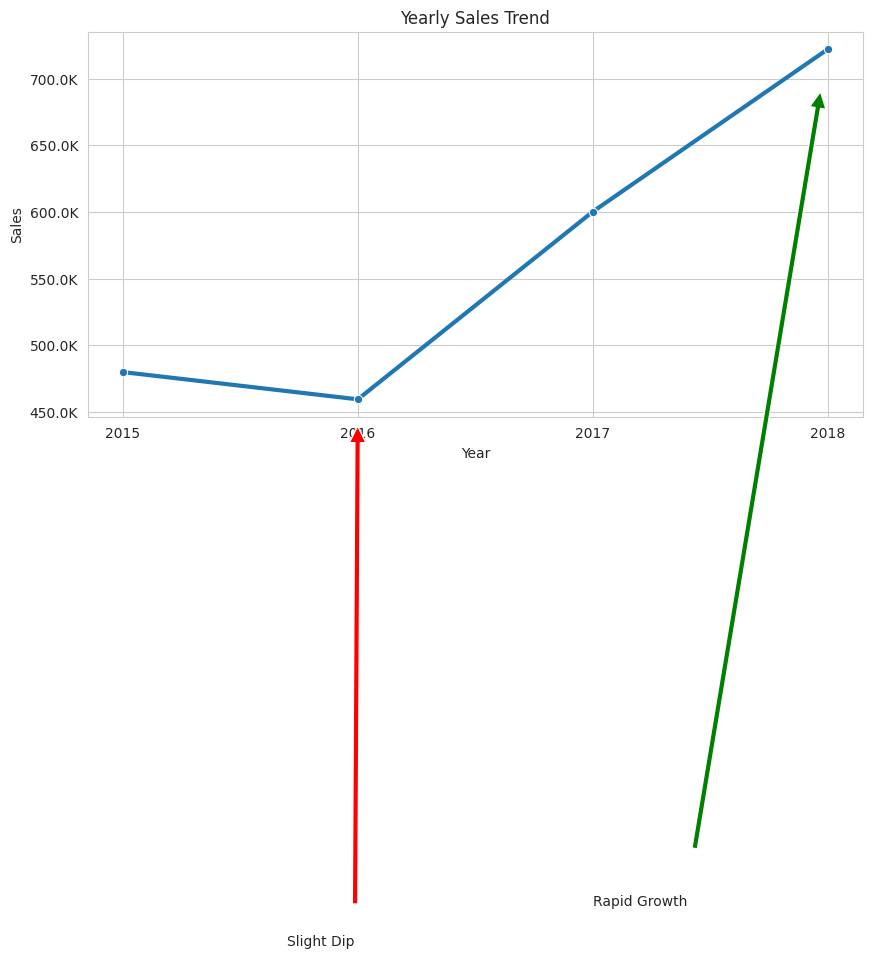

In [ ]:
#Is Business Growing?
#Graph:Yearly sales treand
yearly_sales = df.groupby('order_year')['sales'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(
    data=yearly_sales,
    x='order_year',
    y='sales',
    marker='o',
    linewidth=3
)

# Force integer years
plt.gca().xaxis.set_major_locator(
    ticker.MaxNLocator(integer=True)
)
# Format Y-axis as K
formatter = FuncFormatter(lambda x, pos: f'{x/1000:.1f}K')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales')

plt.annotate(
    'Slight Dip',
    xy=(2016, yearly_sales.loc[yearly_sales['order_year']==2016, 'sales'].values[0]),
    xytext=(2015.7, 50000),
    arrowprops=dict(facecolor='red', shrink=0.05)
)

plt.annotate(
    'Rapid Growth',
    xy=(2018, yearly_sales.loc[yearly_sales['order_year']==2018, 'sales'].values[0]),
    xytext=(2017, 80000),
    arrowprops=dict(facecolor='green', shrink=0.05)
)
plt.show()

Although the business faced a brief setback in 2016, sales momentum increased sharply afterward, suggesting successful recovery strategies and growing customer demand.

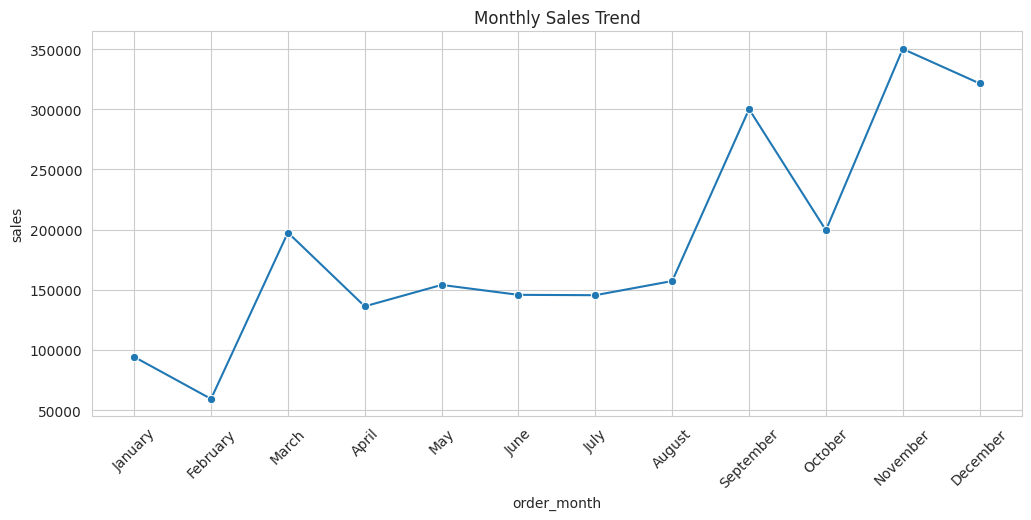

In [ ]:
#When Do Customers Buy Most?
#Graph: Monthly Sales Trend
monthly_sales = df.groupby('order_month')['sales'].sum().reset_index()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales['order_month'] = pd.Categorical(
    monthly_sales['order_month'],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values('order_month')

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='order_month', y='sales', marker='o')

plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')

plt.show()

Sales increase significantly during November and December, suggesting strong holiday season demand.

/tmp/ipykernel_25078/3138698609.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='category', y='sales', palette='viridis')


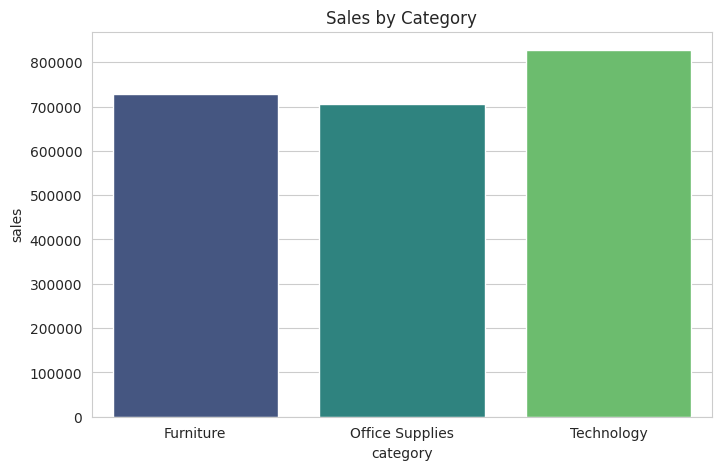

In [ ]:
#Which Categories Drive Revenue?
#Graph: Category Sales
category_sales = df.groupby('category')['sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=category_sales, x='category', y='sales', palette='viridis')

plt.title('Sales by Category')

plt.show()

Technology contributes the highest share of sales, making it the company’s strongest business segment.

/tmp/ipykernel_25078/692870797.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='region', y='sales', palette='coolwarm')


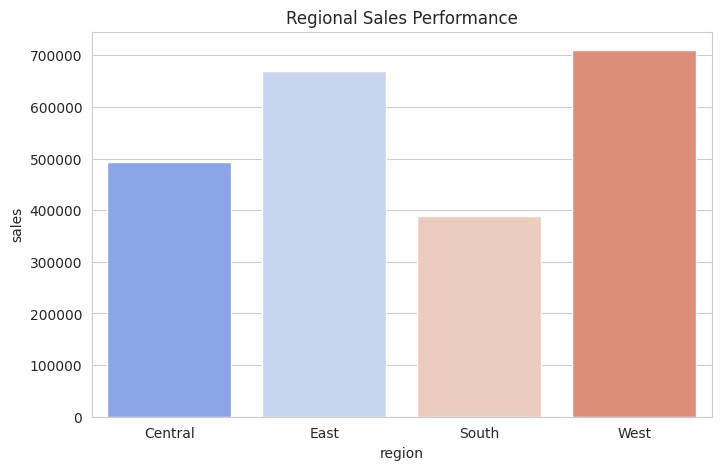

In [ ]:
#Which Regions Perform Best?
#Graph: Regional Sales
region_sales = df.groupby('region')['sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=region_sales, x='region', y='sales', palette='coolwarm')

plt.title('Regional Sales Performance')

plt.show()

The West region generated the highest sales compared to other regions.

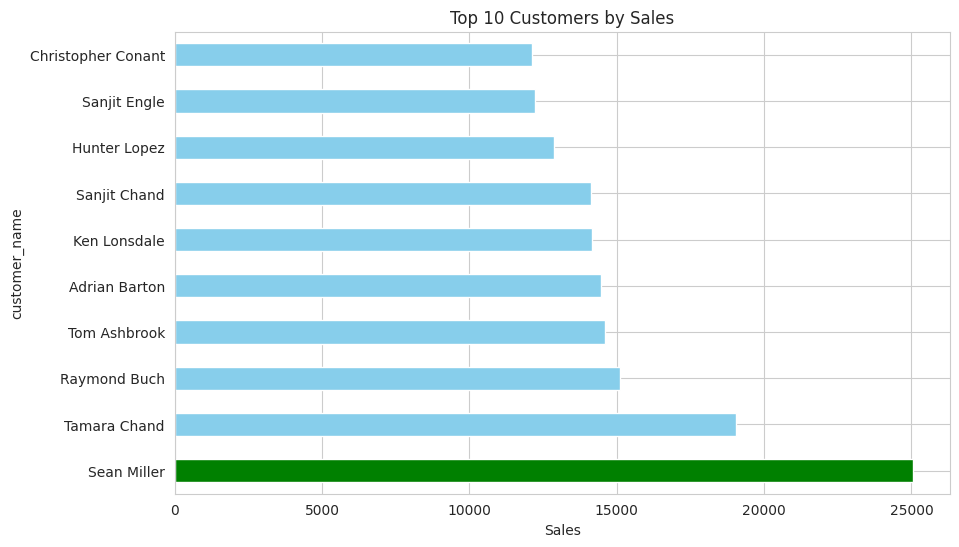

In [ ]:
#Who Are the Top Customers?
#Graph: Top 10 Customers
top_customers = df.groupby('customer_name')['sales'].sum() \
                  .sort_values(ascending=False) \
                  .head(10)

colors = ['green' if i == top_customers.max() else 'skyblue'
          for i in top_customers]

plt.figure(figsize=(10,6))

top_customers.plot(
    kind='barh',
    color=colors
)

plt.title('Top 10 Customers by Sales')
plt.xlabel('Sales')

plt.show()

The business appears to rely heavily on a few key customers, with one customer emerging as the largest revenue contributor.

/tmp/ipykernel_25078/1227743507.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


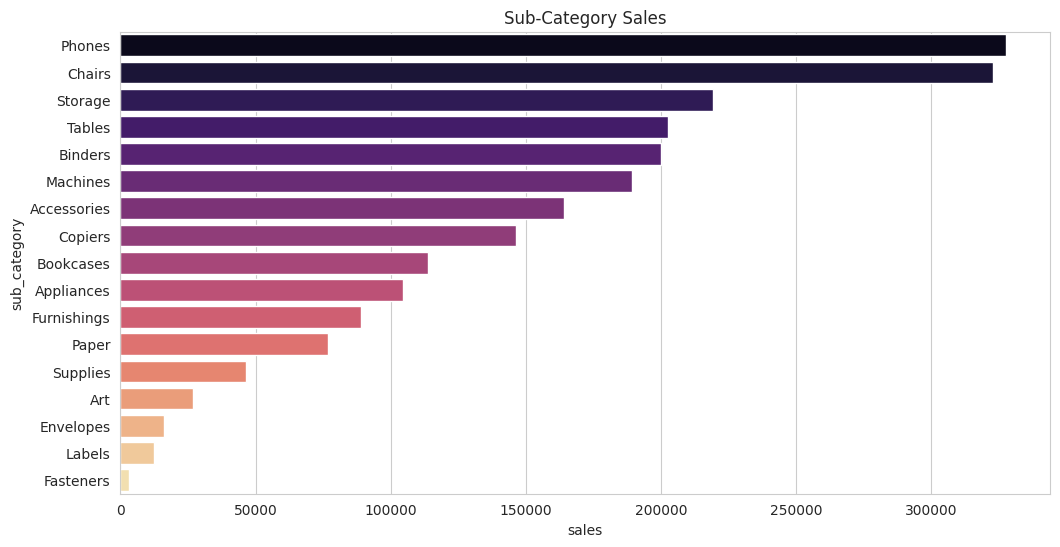

In [ ]:
#Which Products Are Trending?
#Graph: Sub-Category Performance
subcat_sales = df.groupby('sub_category')['sales'].sum().reset_index()

subcat_sales = subcat_sales.sort_values('sales', ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    data=subcat_sales,
    x='sales',
    y='sub_category',
    palette='magma'
)

plt.title('Sub-Category Sales')

plt.show()

Phones and Chairs dominate sales, while smaller categories contribute minimally.

/tmp/ipykernel_25078/3714849640.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(


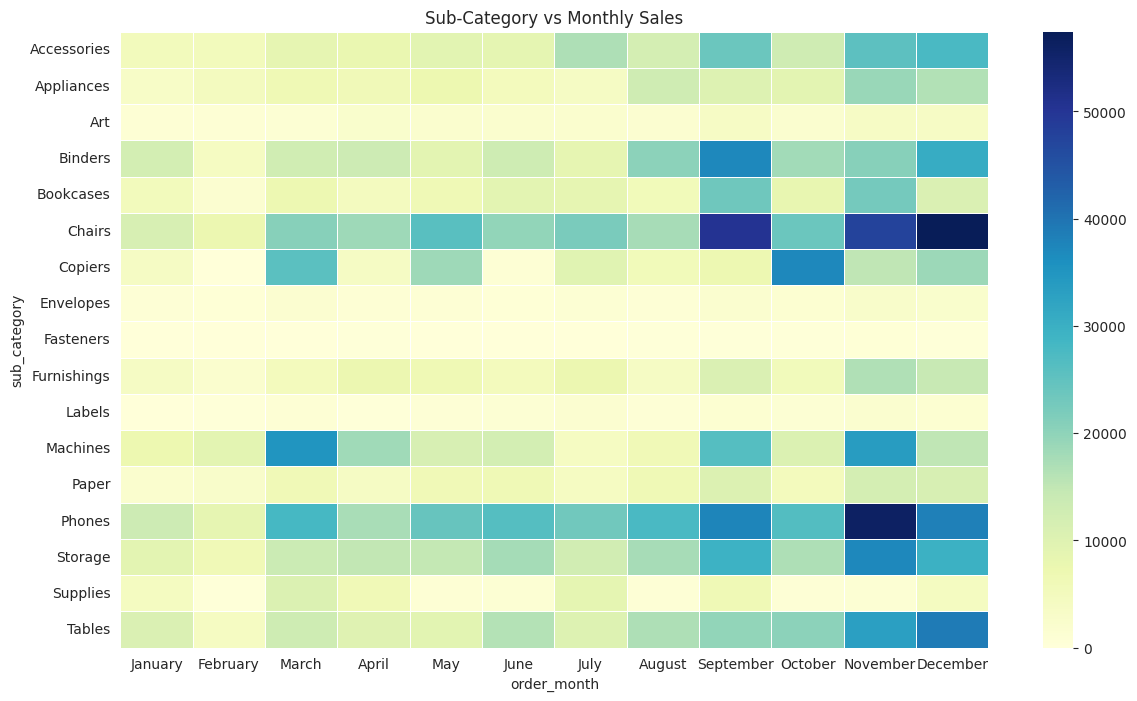

In [ ]:
# Month order
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df['order_month'] = pd.Categorical(
    df['order_month'],
    categories=month_order,
    ordered=True
)

# Pivot table
pivot_table = df.pivot_table(
    values='sales',
    index='sub_category',
    columns='order_month',
    aggfunc='sum'
)

# Plot
plt.figure(figsize=(14,8))

sns.heatmap(
    pivot_table,
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Sub-Category vs Monthly Sales')

plt.show()

In [ ]:
#regional amnalysis
region_sales = df.groupby(['order_year','region'])['sales'].sum().reset_index()

print(region_sales)

    order_year   region        sales
0         2015  Central  102920.5206
1         2015     East  127652.8190
2         2015    South  103374.9055
3         2015     West  145907.9630
4         2016  Central  102425.1724
5         2016     East  153225.1830
6         2016    South   70076.0825
7         2016     West  133709.5675
8         2017  Central  145673.8800
9         2017     East  178511.5380
10        2017    South   93535.9035
11        2017     West  182471.2285
12        2018  Central  141627.3402
13        2018     East  210129.1860
14        2018    South  122164.5675
15        2018     West  248130.9255


In [ ]:
pivot_region = region_sales.pivot(
    index='region',
    columns='order_year',
    values='sales'
)

print(pivot_region)

order_year         2015         2016         2017         2018
region                                                        
Central     102920.5206  102425.1724  145673.8800  141627.3402
East        127652.8190  153225.1830  178511.5380  210129.1860
South       103374.9055   70076.0825   93535.9035  122164.5675
West        145907.9630  133709.5675  182471.2285  248130.9255


In [ ]:
pivot_region['Decrease_%_2016'] = (
    (pivot_region[2016] - pivot_region[2015])
    / pivot_region[2015]
) * 100

print(pivot_region)

order_year         2015         2016         2017         2018  \
region                                                           
Central     102920.5206  102425.1724  145673.8800  141627.3402   
East        127652.8190  153225.1830  178511.5380  210129.1860   
South       103374.9055   70076.0825   93535.9035  122164.5675   
West        145907.9630  133709.5675  182471.2285  248130.9255   

order_year  Decrease_%_2016  
region                       
Central           -0.481292  
East              20.032745  
South            -32.211708  
West              -8.360336  


In [ ]:
pivot_region['Decrease_%_2016'] = (
    pivot_region['Decrease_%_2016']
    .round(2)
)

print(pivot_region)

order_year         2015         2016         2017         2018  \
region                                                           
Central     102920.5206  102425.1724  145673.8800  141627.3402   
East        127652.8190  153225.1830  178511.5380  210129.1860   
South       103374.9055   70076.0825   93535.9035  122164.5675   
West        145907.9630  133709.5675  182471.2285  248130.9255   

order_year  Decrease_%_2016  
region                       
Central               -0.48  
East                  20.03  
South                -32.21  
West                  -8.36  


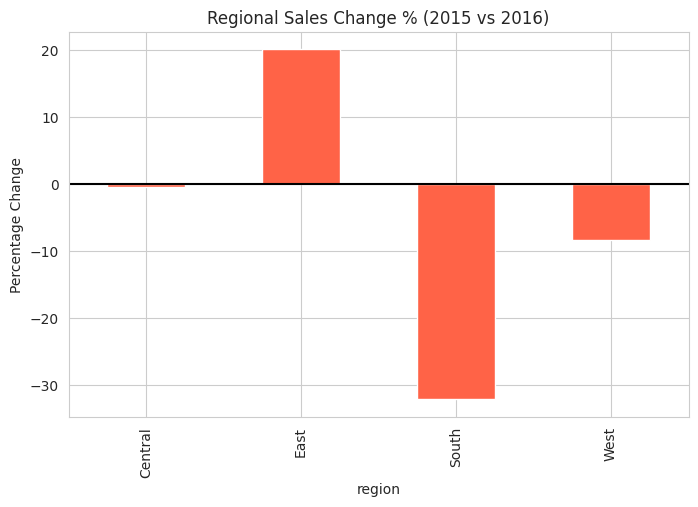

In [ ]:
pivot_region['Decrease_%_2016'].plot(
    kind='bar',
    figsize=(8,5),
    color='tomato'
)

plt.title('Regional Sales Change % (2015 vs 2016)')
plt.ylabel('Percentage Change')
plt.axhline(0, color='black')
plt.show()

In [ ]:
#category analysis
category_sales = df.groupby(['order_year','category'])['sales'].sum().reset_index()

print(category_sales)

    order_year         category        sales
0         2015        Furniture  156477.8811
1         2015  Office Supplies  149512.8200
2         2015       Technology  173865.5070
3         2016        Furniture  164053.8674
4         2016  Office Supplies  133124.4070
5         2016       Technology  162257.7310
6         2017        Furniture  195813.0400
7         2017  Office Supplies  182417.5660
8         2017       Technology  221961.9440
9         2018        Furniture  212313.7872
10        2018  Office Supplies  240367.5410
11        2018       Technology  269370.6910


In [ ]:
pivot_category = category_sales.pivot(
    index='category',
    columns='order_year',
    values='sales'
)

print(pivot_category)

order_year              2015         2016        2017         2018
category                                                          
Furniture        156477.8811  164053.8674  195813.040  212313.7872
Office Supplies  149512.8200  133124.4070  182417.566  240367.5410
Technology       173865.5070  162257.7310  221961.944  269370.6910


In [ ]:
pivot_category['Decrease_%_2016'] = (
    (pivot_category[2016] - pivot_category[2015])
    / pivot_category[2015]
) * 100

print(pivot_category)

order_year              2015         2016        2017         2018  \
category                                                             
Furniture        156477.8811  164053.8674  195813.040  212313.7872   
Office Supplies  149512.8200  133124.4070  182417.566  240367.5410   
Technology       173865.5070  162257.7310  221961.944  269370.6910   

order_year       Decrease_%_2016  
category                          
Furniture               4.841570  
Office Supplies       -10.961209  
Technology             -6.676296  


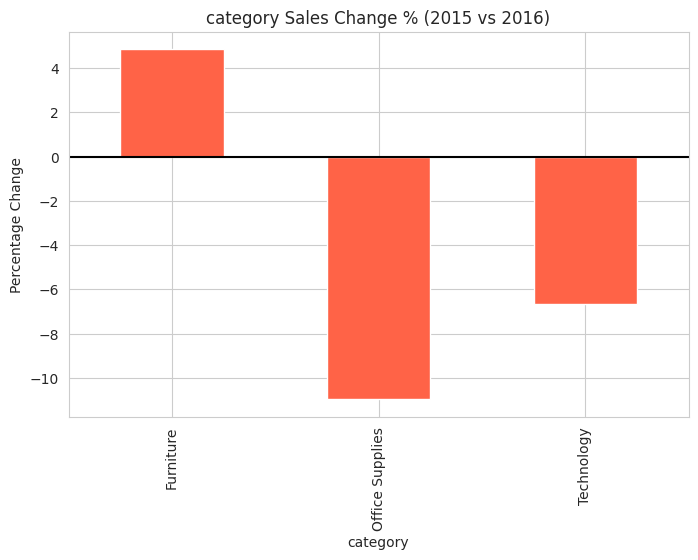

In [ ]:
pivot_category['Decrease_%_2016'].plot(
    kind='bar',
    figsize=(8,5),
    color='tomato'
)

plt.title('category Sales Change % (2015 vs 2016)')
plt.ylabel('Percentage Change')
plt.axhline(0, color='black')
plt.show()

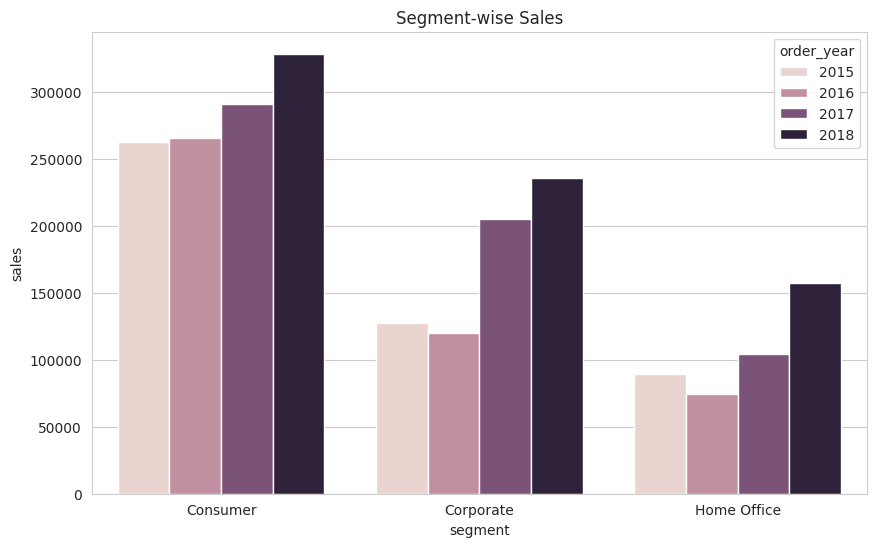

In [ ]:
#segment analysis
segment_sales = df.groupby(['order_year','segment'])['sales'].sum().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_sales,
    x='segment',
    y='sales',
    hue='order_year'
)

plt.title('Segment-wise Sales')
plt.show()

In [ ]:
#sate analysis
state_sales = df.groupby(['order_year','state'])['sales'].sum().reset_index()

In [ ]:
sales_2016 = state_sales[state_sales['order_year'] == 2016]

top_states = sales_2016.sort_values(
    by='sales',
    ascending=False
).head(10)

print(top_states)

    order_year         state       sales
47        2016    California  85621.5825
74        2016      New York  77416.3550
83        2016         Texas  34005.9094
79        2016  Pennsylvania  20500.4480
87        2016    Washington  19981.0940
55        2016      Illinois  18578.0640
64        2016      Michigan  16843.6790
76        2016          Ohio  15918.2520
52        2016       Florida  14239.8405
53        2016       Georgia  11077.7400


In [ ]:
#order count analysis
orders = df.groupby('order_year')['order_id'].nunique()

print(orders)

order_year
2015     947
2016    1019
2017    1295
2018    1661
Name: order_id, dtype: int64


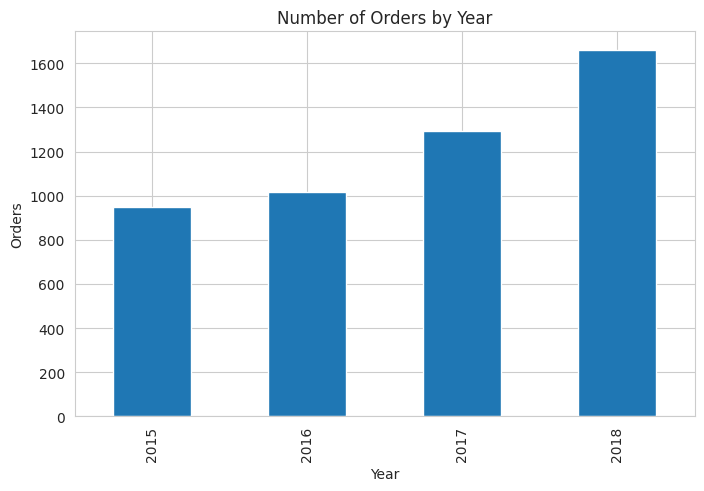

In [ ]:
orders.plot(kind='bar', figsize=(8,5))

plt.title('Number of Orders by Year')
plt.ylabel('Orders')
plt.xlabel('Year')
plt.show()

In [ ]:
summary = df.groupby(['order_year', 'region']).agg(
    Orders=('order_id', 'nunique'),
    Sales=('sales', 'sum')
).reset_index()

In [ ]:
print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'order_year', 'order_month']


In [ ]:
print(df.columns.tolist())
print(summary.columns.tolist())
print(summary.head())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'order_year', 'order_month']
['order_year', 'region', 'Orders', 'Sales']
   order_year   region  Orders        Sales
0        2015  Central     223  102920.5206
1        2015     East     255  127652.8190
2        2015    South     161  103374.9055
3        2015     West     308  145907.9630
4        2016  Central     233  102425.1724


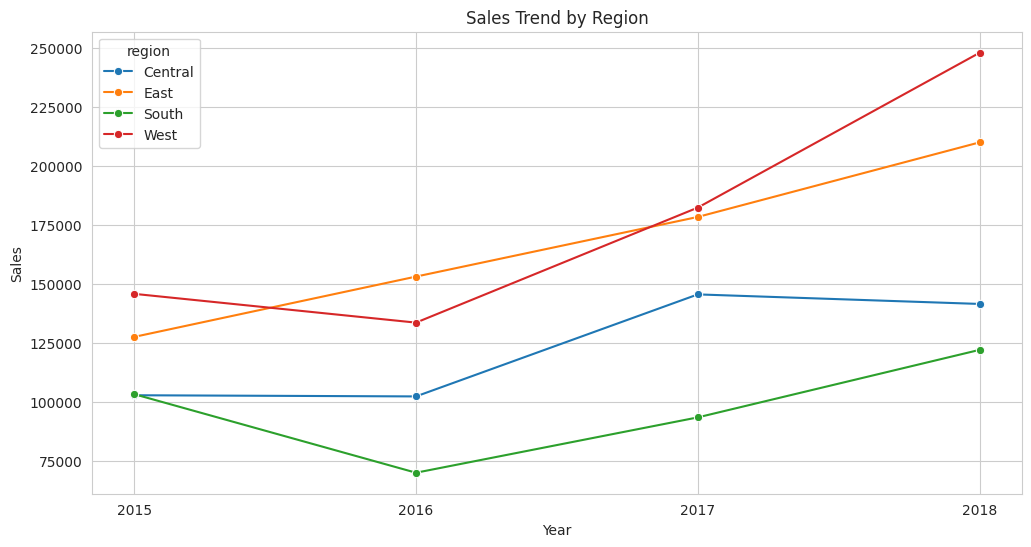

In [ ]:
summary['order_year'] = summary['order_year'].astype(str)
fig, ax1 = plt.subplots(figsize=(12,6))

sns.lineplot(
    data=summary,
    x='order_year',
    y='Sales',
    hue='region',
    marker='o',
    ax=ax1
)

plt.title('Sales Trend by Region')
plt.xlabel('Year')
plt.show()

In [ ]:
orders_summary = df.groupby(['order_year', 'region']).agg(
    Orders=('order_date', 'count')
).reset_index()

print(orders_summary)

    order_year   region  Orders
0         2015  Central     455
1         2015     East     506
2         2015    South     344
3         2015     West     648
4         2016  Central     474
5         2016     East     626
6         2016    South     330
7         2016     West     625
8         2017  Central     591
9         2017     East     745
10        2017    South     411
11        2017     West     787
12        2018  Central     757
13        2018     East     908
14        2018    South     513
15        2018     West    1080


In [ ]:
yearly_orders = df.groupby('order_year').size().reset_index(name='Orders')
print(yearly_orders)

   order_year  Orders
0        2015    1953
1        2016    2055
2        2017    2534
3        2018    3258


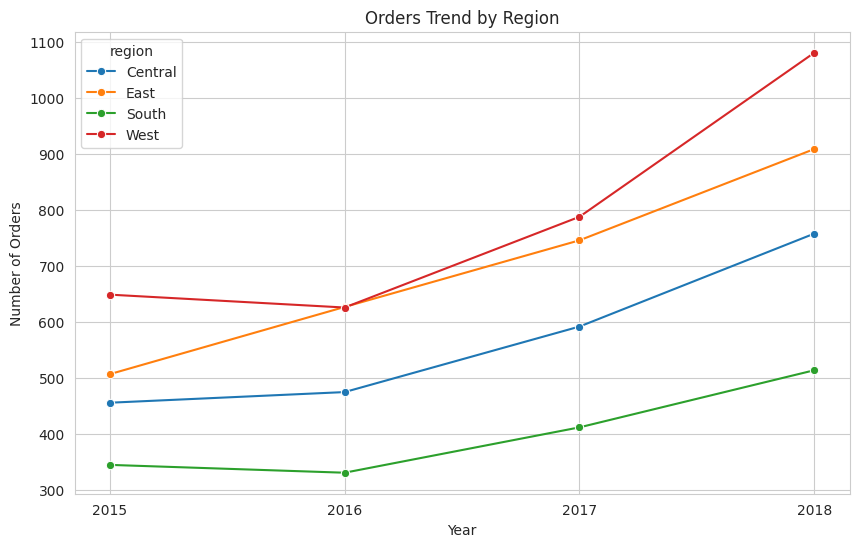

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.lineplot(
    data=orders_summary,
    x='order_year',
    y='Orders',
    hue='region',
    marker='o'
)

years = sorted(orders_summary['order_year'].unique())
ax.set_xticks(years)

plt.title('Orders Trend by Region')
plt.ylabel('Number of Orders')
plt.xlabel('Year')
plt.show()

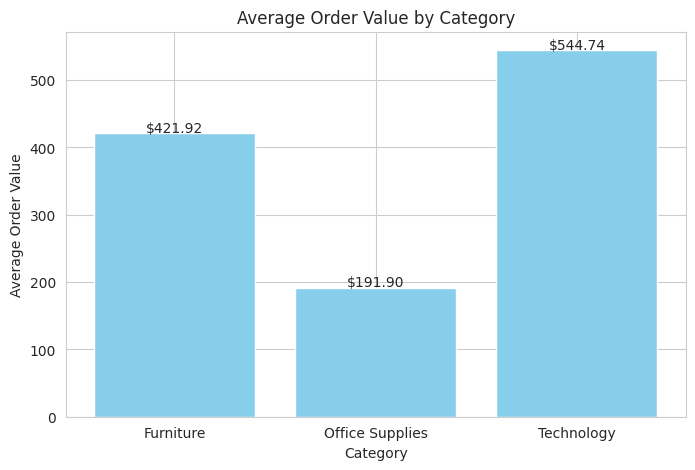

In [ ]:
# Calculate AOV by Category
aov_data = df.groupby('category').agg({
    'sales': 'sum',
    'order_id': 'nunique'
})

# Calculate Average Order Value
aov_data['AOV'] = (
    aov_data['sales'] /
    aov_data['order_id']
)

# Plot graph
plt.figure(figsize=(8,5))

bars = plt.bar(
    aov_data.index,
    aov_data['AOV'],
    color='skyblue'
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'${height:.2f}',
        ha='center'
    )

plt.title('Average Order Value by Category')
plt.xlabel('Category')
plt.ylabel('Average Order Value')

plt.show()

In [ ]:
south_office = df [
(df["region"]== "South")&
(df["category"]=="Office Supplies")
]


In [ ]:
sales = south_office.groupby("order_year")["sales"].sum()
print(sales.values)

[25785.798 30228.585 28637.876 39772.512]


In [ ]:
orders = south_office.groupby("order_year")["order_id"].nunique()
print(orders)

order_year
2015    125
2016    125
2017    159
2018    204
Name: order_id, dtype: int64


In [ ]:
south_office.groupby("order_year").agg(
    sales=("sales", "sum"),
    orders=("order_id", "nunique")  # or .size() if no order_id
)

,sales,orders
order_year,,
2015,25785.798,125
2016,30228.585,125
2017,28637.876,159
2018,39772.512,204


In [ ]:
south_office = df [
(df["region"]== "South")&
(df["category"]=="Furniture")
]
south_office.groupby("order_year").agg(
    sales=("sales", "sum"),
    orders=("order_id", "nunique")  # or .size() if no order_id
)

,sales,orders
order_year,,
2015,26942.7545,54
2016,23844.6265,59
2017,27875.8735,72
2018,37868.2255,87


In [ ]:
#south region technology category analysis.
south_office = df [
(df["region"]== "South")&
(df["category"]=="Technology")
]
south_office.groupby("order_year").agg(
    sales=("sales", "sum"),
    orders=("order_id", "nunique")  # or .size() if no order_id
)

,sales,orders
order_year,,
2015,50646.353,55
2016,16002.871,49
2017,37022.154,67
2018,44523.830,81


In [ ]:
south = df[df["region"] == "South"]

In [ ]:
yearly_sales = df.groupby('order_year')['sales'].sum()

orders = df.groupby('order_year')['order_id'].nunique()

aov = yearly_sales / orders

print(aov)

order_year
2015    506.711941
2016    450.869485
2017    463.469151
2018    434.709223
dtype: float64


Average customer spending per order declined significantly in 2016.

In [ ]:
south = df[df['region'] == 'South']

south_yearly = south.groupby('order_year')['sales'].sum()

print(south_yearly)

order_year
2015    103374.9055
2016     70076.0825
2017     93535.9035
2018    122164.5675
Name: sales, dtype: float64


In [ ]:
south_growth = south_yearly.pct_change() * 100

print(south_growth)

order_year
2015          NaN
2016   -32.211708
2017    33.477643
2018    30.607139
Name: sales, dtype: float64


In [ ]:
office = df[df['category'] == 'Technology']

office_yearly = office.groupby('order_year')['sales'].sum()

print(office_yearly)

order_year
2015    173865.507
2016    162257.731
2017    221961.944
2018    269370.691
Name: sales, dtype: float64


In [ ]:
office_growth = office_yearly.pct_change() * 100

print(office_growth)

order_year
2015          NaN
2016    -6.676296
2017    36.795913
2018    21.358953
Name: sales, dtype: float64


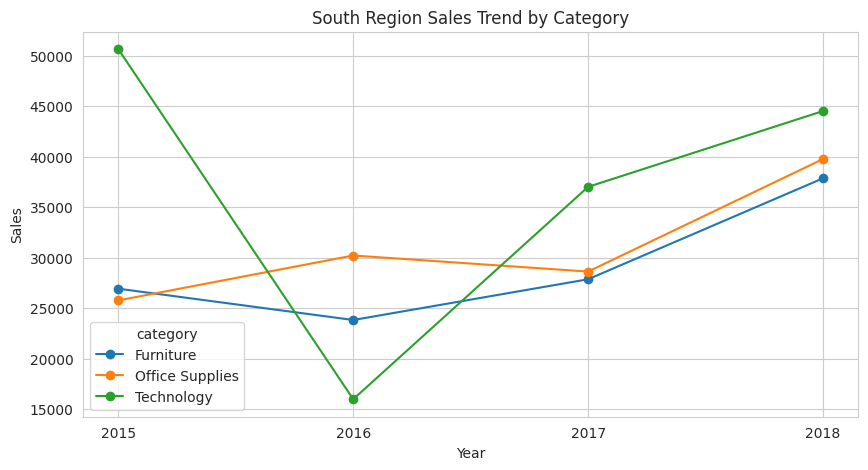

In [ ]:
sales_trend = south.groupby(["order_year", "category"])["sales"].sum().unstack()

sales_trend.plot(marker="o", figsize=(10,5))
plt.title("South Region Sales Trend by Category")
plt.ylabel("Sales")
plt.xlabel("Year")
plt.xticks([2015, 2016, 2017, 2018])
plt.show()

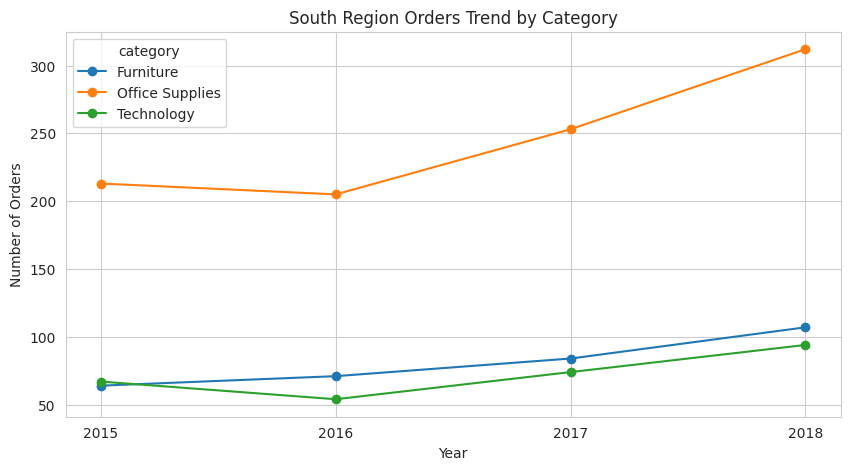

In [ ]:
orders_trend = south.groupby(["order_year", "category"]).size().unstack()

orders_trend.plot(marker="o", figsize=(10,5))
plt.title("South Region Orders Trend by Category")
plt.ylabel("Number of Orders")
plt.xlabel("Year")
plt.xticks([2015, 2016, 2017, 2018])
plt.show()

The 2016 sales decline was caused by slitly reduced order volume.and more due to customers spent less per transaction. The decline was concentrated in the South region and Technology category.

In [ ]:
#shipping delay
df['shipping_days'] = (
    df['ship_date'] - df['order_date']
).dt.days

In [ ]:
shipping = df.groupby('order_year')['shipping_days'].mean()

print(shipping)

order_year
2015    3.995904
2016    4.036010
2017    3.945541
2018    3.905157
Name: shipping_days, dtype: float64


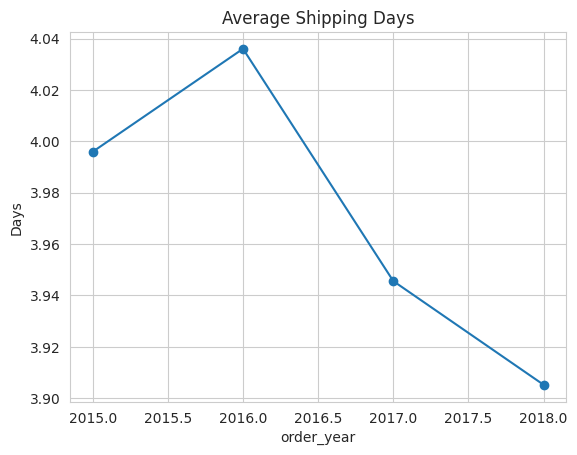

In [ ]:
shipping.plot(kind='line', marker='o')

plt.title('Average Shipping Days')
plt.ylabel('Days')
plt.show()

shipping days also increased in 2016.

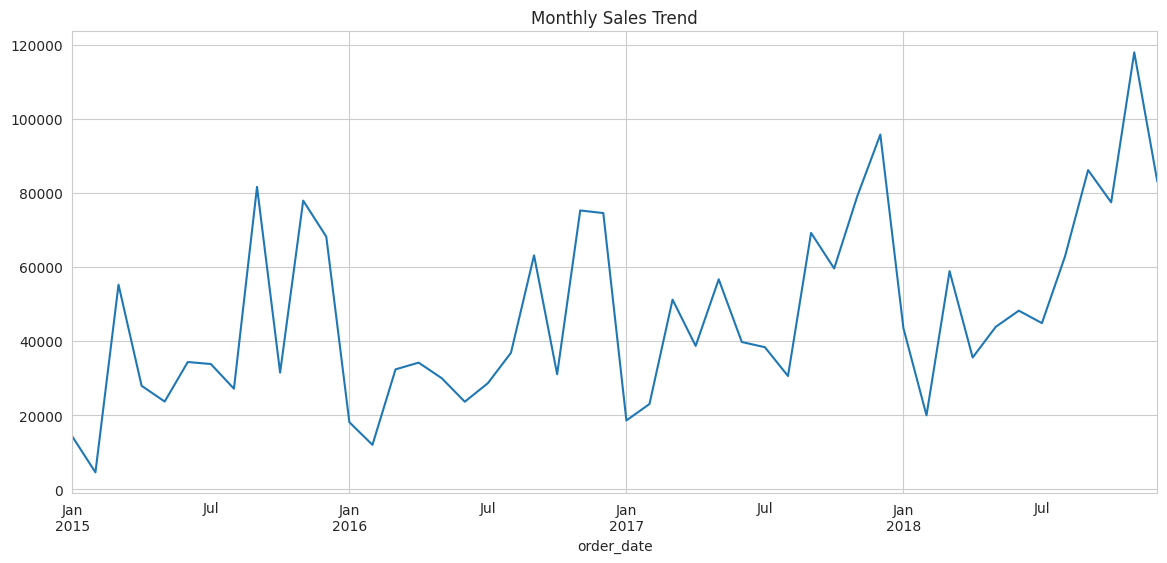

In [ ]:
monthly_sales = df.groupby(
    [df['order_date'].dt.to_period('M')]
)['sales'].sum()

monthly_sales.plot(figsize=(14,6))

plt.title('Monthly Sales Trend')
plt.show()

In [ ]:
#subcategory analysis
office_sub = df[
    df['category'] == 'Technology'
]

subcat = office_sub.groupby(
    ['order_year', 'sub_category']
)['sales'].sum().reset_index()

In [ ]:
pivot_sub = subcat.pivot(
    index='sub_category',
    columns='order_year',
    values='sales'
)

In [ ]:
pivot_sub['YoY_2016_%'] = (
    (pivot_sub[2016] - pivot_sub[2015])
    / pivot_sub[2015]
) * 100

In [ ]:
pivot_sub.sort_values(
    by='YoY_2016_%'
).head(10)

order_year,2015,2016,2017,2018,YoY_2016_%
sub_category,,,,,
Machines,62023.373,27763.697,55906.886,43544.675,-55.236719
Phones,77225.956,67870.614,78000.220,104685.658,-12.114246
Accessories,23766.396,40443.970,41735.364,58240.970,70.172920
Copiers,10849.782,26179.450,46319.474,62899.388,141.290101


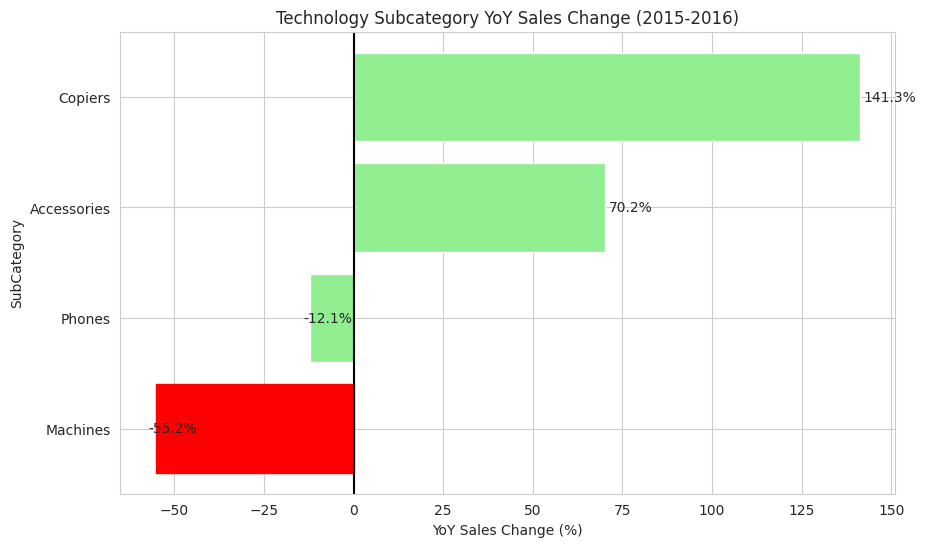

In [ ]:
# Sort values
plot_data = pivot_sub.sort_values(
    by='YoY_2016_%'
).head(10)

# Plot
plt.figure(figsize=(10,6))

bars = plt.barh(
    plot_data.index,
    plot_data['YoY_2016_%'],
    color='lightgreen'
)

# Highlight Machines
for bar, name in zip(bars, plot_data.index):
    if name == 'Machines':
        bar.set_color('red')

# Add percentage labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width - 2 if width < 0 else width + 1,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center'
    )

plt.title('Technology Subcategory YoY Sales Change (2015-2016)')
plt.xlabel('YoY Sales Change (%)')
plt.ylabel('SubCategory')

plt.axvline(0, color='black')

plt.show()

In 2016, the Technology category experienced a sales decline compared to 2015 in south region. Among all Technology subcategories, Machines recorded the highest negative Year-over-Year sales growth, indicating the largest decrease in sales performance and in 2016 in south region in technology category orders also declined slitly that also may be the reson for sales decrement.
Even purchaced with lesser amount product may also be the the reason for sales decline.